In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import seaborn as sns
from scipy import stats






df = pd.read_csv('DayxNightFatality.csv', sep = ",")
df.columns = ['YEAR', 'DAYLIGHT', 'ACCIDENTS', 'FATALITIES', 'RATE']


df["ACCIDENTS"] = df["ACCIDENTS"].str.replace(",", "").astype(float)
df["FATALITIES"] = df["FATALITIES"].str.replace(",", "").astype(float)


df.head()


df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   YEAR        10 non-null     int64  
 1   DAYLIGHT    10 non-null     object 
 2   ACCIDENTS   10 non-null     float64
 3   FATALITIES  10 non-null     float64
 4   RATE        10 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 532.0+ bytes


In [12]:
day= df[df['DAYLIGHT'] == 'Day']
night= df[df['DAYLIGHT'] == 'Night']

print (day)


print (night)

   YEAR DAYLIGHT  ACCIDENTS  FATALITIES      RATE
0  2020      Day   100578.0      2793.0  0.027769
2  2021      Day   129444.0      3193.0  0.024667
4  2022      Day   132009.0      3054.0  0.023135
6  2023      Day   154878.0      3781.0  0.024413
8  2024      Day   174332.0      3672.0  0.021063
   YEAR DAYLIGHT  ACCIDENTS  FATALITIES      RATE
1  2020    Night    45623.0      1905.0  0.041755
3  2021    Night    53403.0      1963.0  0.036758
5  2022    Night    60415.0      1992.0  0.032972
7  2023    Night    74844.0      2540.0  0.033937
9  2024    Night    86916.0      2476.0  0.028487


In [13]:
yearly_accidents = df.groupby("YEAR")["ACCIDENTS"].sum()

yearly_accidents

,ACCIDENTS
YEAR,
2020,146201.0
2021,182847.0
2022,192424.0
2023,229722.0
2024,261248.0


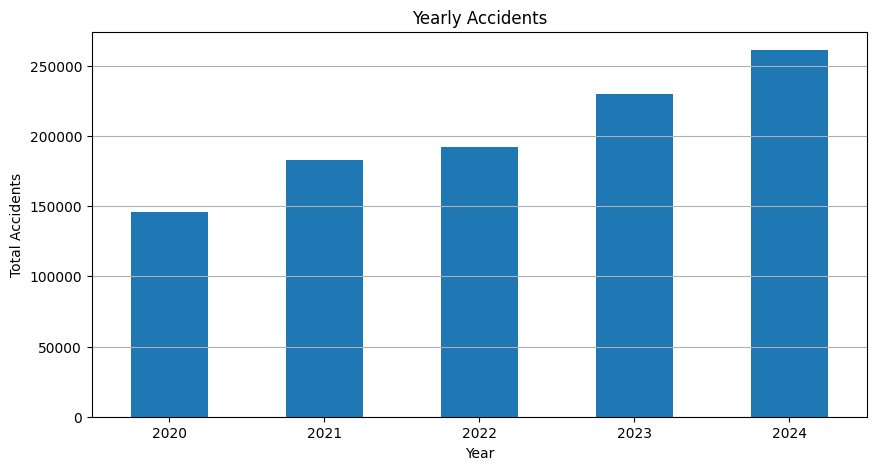

In [14]:
yearly_accidents.plot(kind = "bar", figsize = (10, 5))

plt.title("Yearly Accidents")
plt.xlabel("Year")
plt.ylabel("Total Accidents")

plt.xticks(rotation=0)
plt.grid(axis = "y")

plt.show()

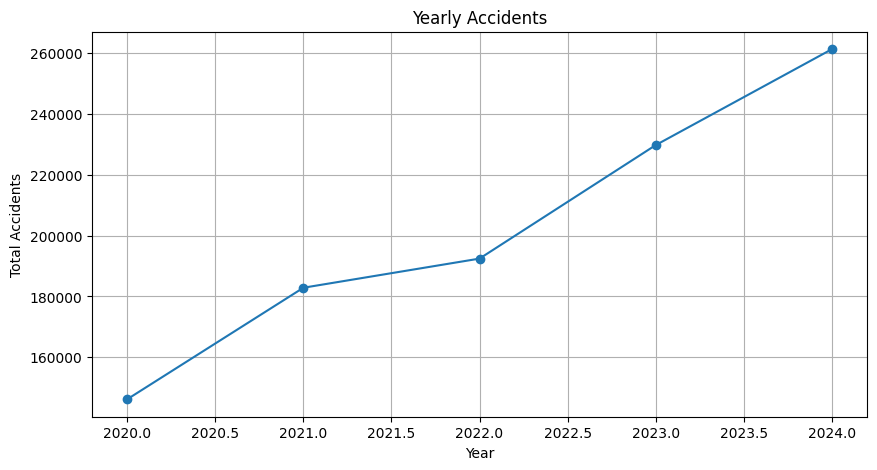

In [15]:
yearly_accidents.plot(marker="o", figsize=(10, 5))

plt.title("Yearly Accidents")
plt.xlabel("Year")
plt.ylabel("Total Accidents")

plt.grid(True)
plt.show()

Text(0, 0.5, 'Total Accidents')

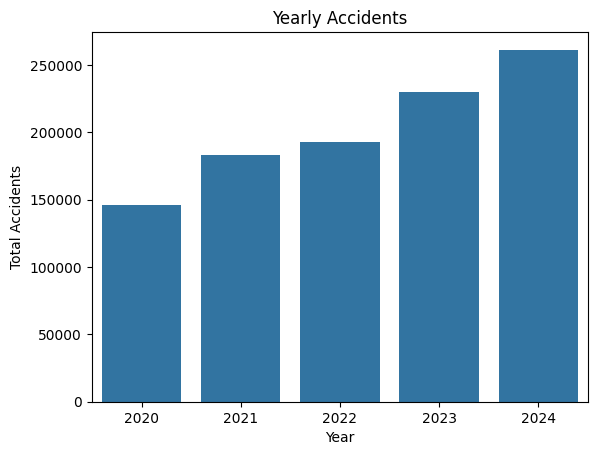

In [16]:
sns.barplot(x=yearly_accidents.index, y=yearly_accidents.values)

plt.title("Yearly Accidents")
plt.xlabel("Year")
plt.ylabel("Total Accidents")

# **The total number of traffic accidents shows a clear increasing trend from 2020 to 2024 indicating a rise in traffic activity over time.**

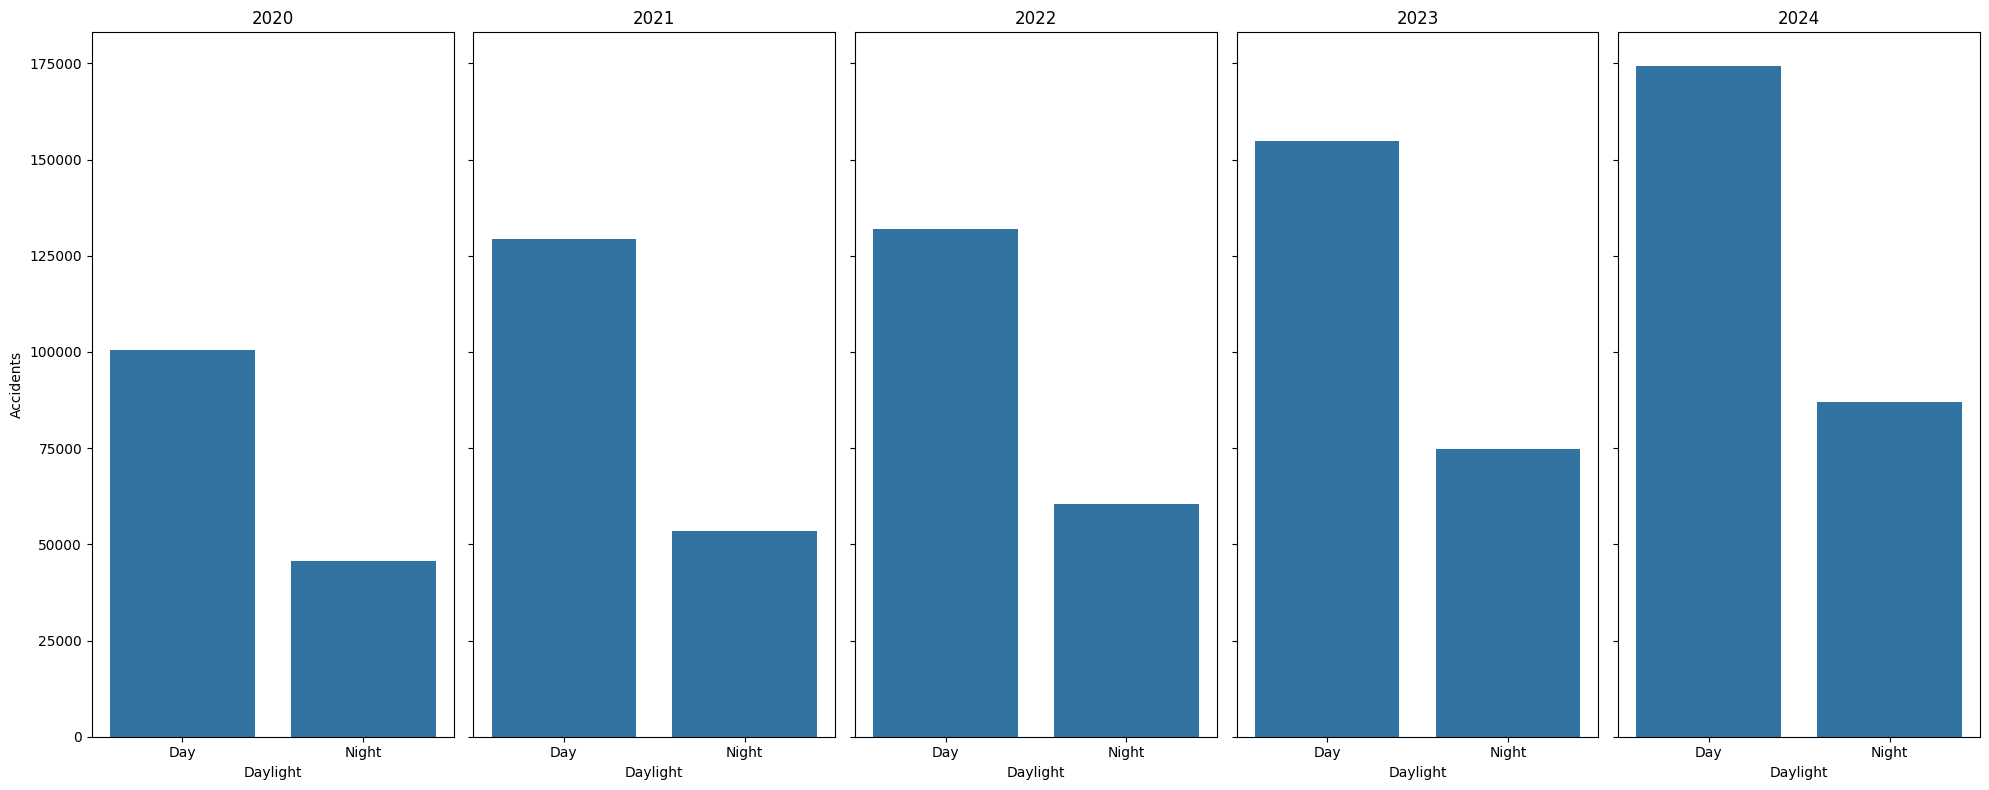

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 8), sharey=True)

years = sorted(df["YEAR"].unique())

for i, year in enumerate(years):
    year_data = df[df["YEAR"] == year]

    sns.barplot(
        data=year_data,
        x="DAYLIGHT",
        y="ACCIDENTS",
        ax=axes[i]
    )

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Daylight")
    axes[i].set_ylabel("Accidents")

plt.tight_layout()
plt.show()

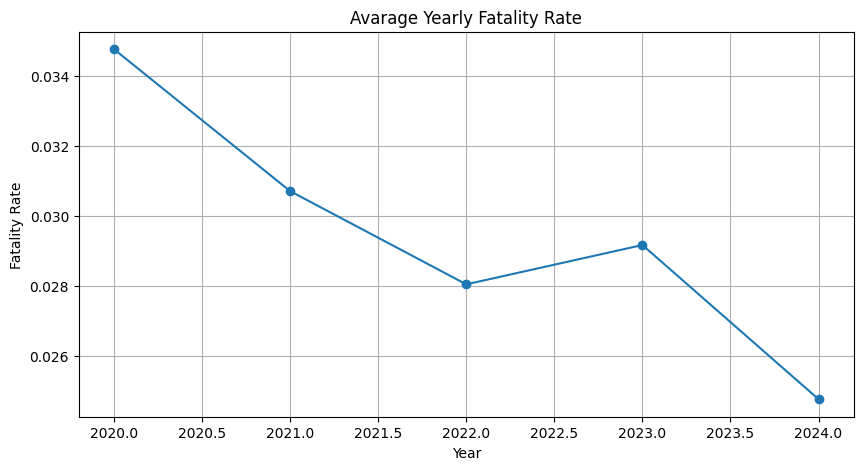

In [20]:
yearly_rate = df.groupby("YEAR")["RATE"].mean()

yearly_rate

yearly_rate.plot(marker="o", figsize=(10, 5))

plt.title("Avarage Yearly Fatality Rate")
plt.xlabel("Year")
plt.ylabel("Fatality Rate")

plt.grid(True)
plt.show()

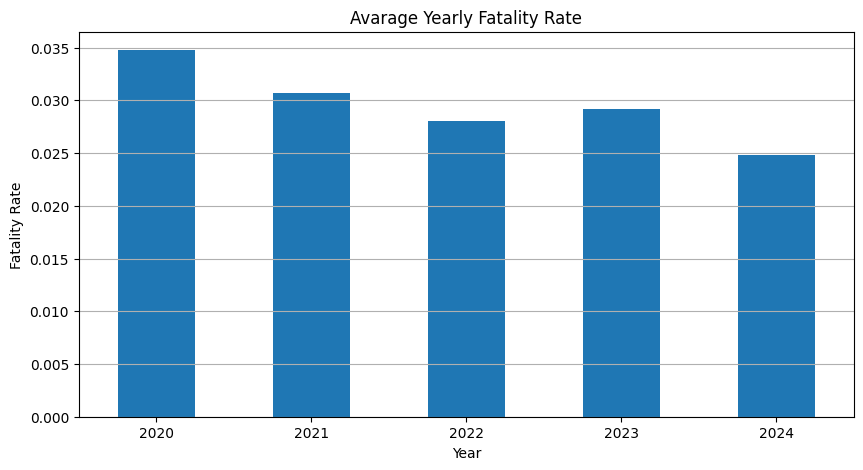

In [21]:
yearly_rate.plot(kind="bar", figsize=(10, 5))

plt.title("Avarage Yearly Fatality Rate")
plt.xlabel("Year")
plt.ylabel("Fatality Rate")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

Text(0, 0.5, 'Fatality Rate')

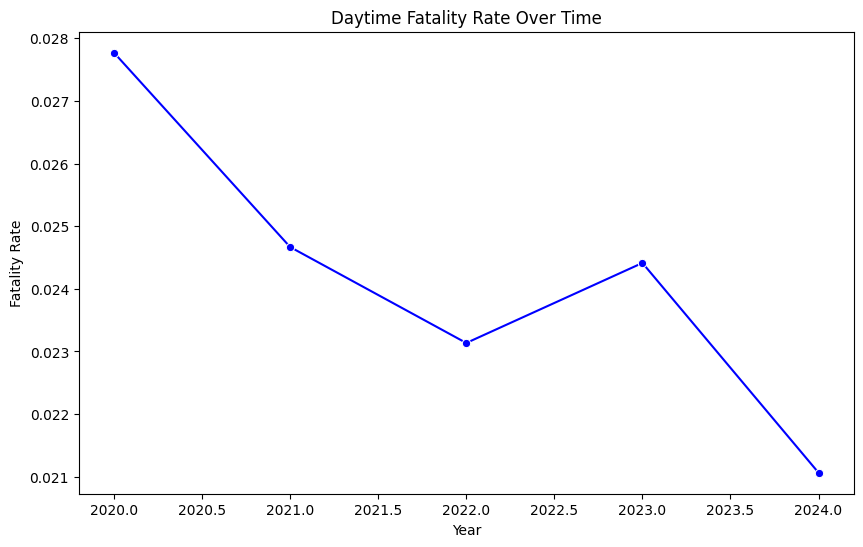

In [22]:
from numpy._core.defchararray import title
day_df = df[df["DAYLIGHT"] == "Day"]

plt.figure(figsize=(10, 6))
sns.lineplot(data=day_df, x="YEAR", y="RATE", marker="o", color="blue")
plt.title("Daytime Fatality Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Fatality Rate")


Text(0, 0.5, 'Fatality Rate')

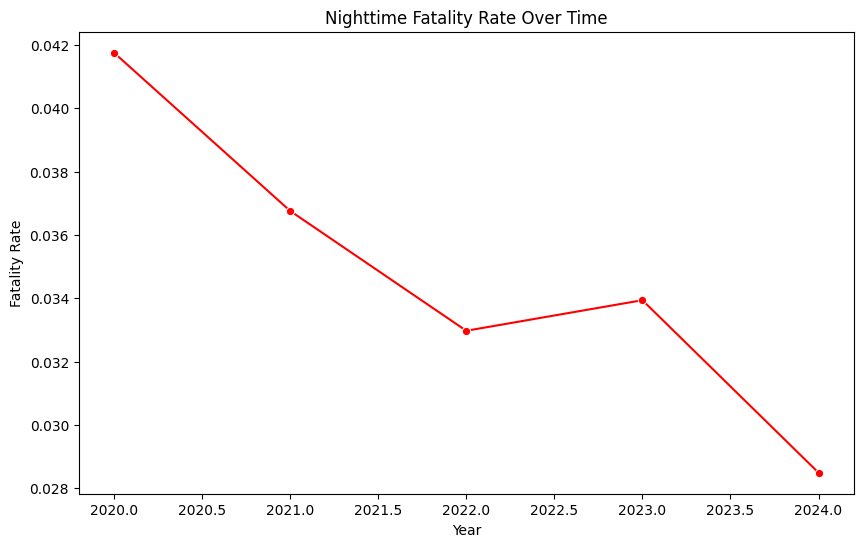

In [24]:
night_df=df[df["DAYLIGHT"] == "Night"]
plt.figure(figsize=(10, 6))
sns.lineplot(data=night_df, x="YEAR", y="RATE", marker="o", color="red")
plt.title("Nighttime Fatality Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Fatality Rate")

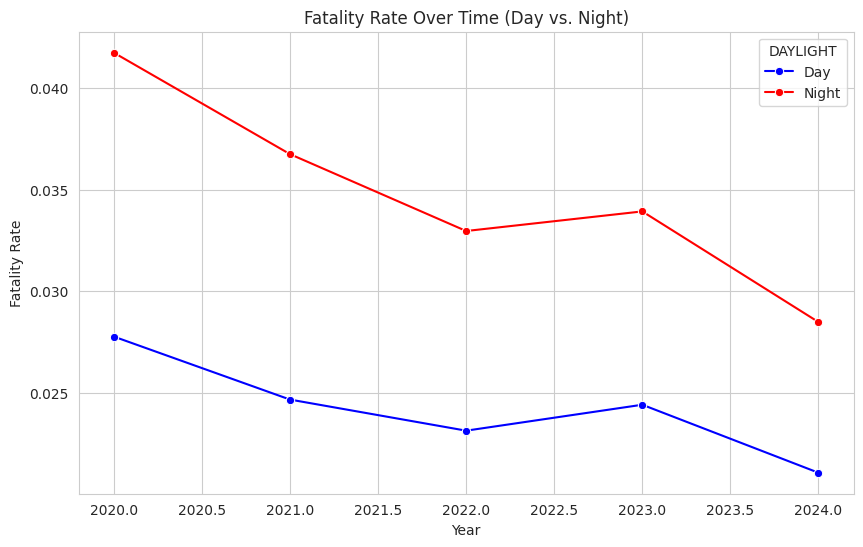

In [25]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x="YEAR", y="RATE", hue="DAYLIGHT", marker="o", palette=["blue", "red"])

plt.title("Fatality Rate Over Time (Day vs. Night)")
plt.xlabel("Year")
plt.ylabel("Fatality Rate")

plt.grid(True)
plt.show()

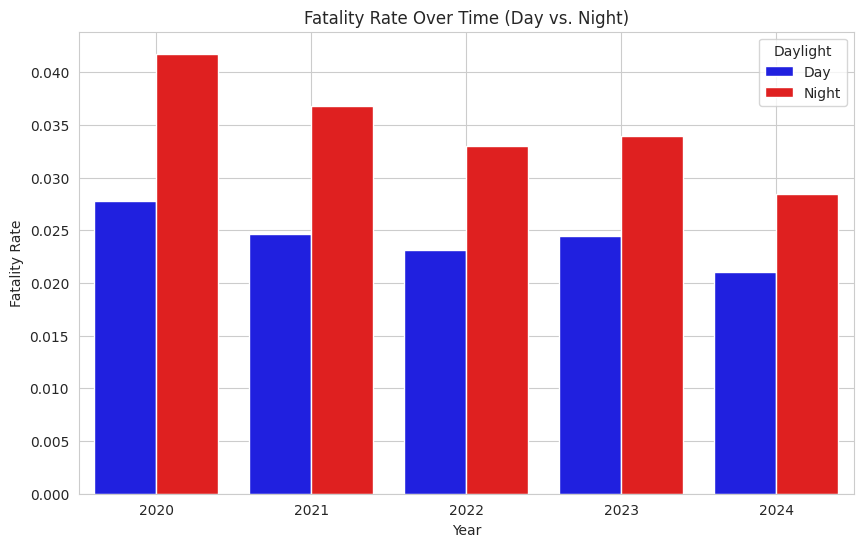

In [26]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="YEAR", y="RATE", hue="DAYLIGHT", palette=["blue", "red"])

plt.title("Fatality Rate Over Time (Day vs. Night)")
plt.xlabel("Year")
plt.ylabel("Fatality Rate")

plt.legend(title="Daylight")

plt.grid(True)
plt.show()

# MORE UNDERSTANDABLE VERSION

# **The bar chart clearly shows that nighttime fatality rates are consistently higher than daytime rates for each year.**

# **NOW SOME TESTS WILL BE APPLIED TO SEE IF THERE IS ANY CORRELATION**

In [27]:
day = df[df["DAYLIGHT"] == "Day"]["RATE"]
night = df[df["DAYLIGHT"] == "Night"]["RATE"]
t_stat, p_value = stats.ttest_ind(day, night)
print("T-Stat:", t_stat)
print("P-Value:", p_value)


T-Stat: -4.313999850777076
P-Value: 0.002566762641802234


# **P = 0.0025 < 0.05, SO THIS T-TEST RESULT INDICATES THAT THERE IS SIGNIFICANT DIFFERENCE BETWEEN DAY TIME AND NIGHT TIME ACCIDENTS FATALITY RATE, SO H0 IS FAILED FOR THIS TEST **

In [29]:
df["DAYLIGHT_NUM"] = df['DAYLIGHT'].map({'Day': 0, 'Night': 1})

pearson_corr = df['DAYLIGHT_NUM'].corr(df["RATE"])
print("Pearson Correlation:", pearson_corr)

Pearson Correlation: 0.8362821660891486


In [30]:
from scipy.stats import spearmanr

spearman_corr, p_value = spearmanr(df["DAYLIGHT_NUM"], df["RATE"])
print("Spearman Correlation:", spearman_corr)
print("P-Value:", p_value)

Spearman Correlation: 0.8703882797784891
P-Value: 0.001052825793366541


# **BOTH PEARSON AND SPEARMAN CORRELATIONS INDICATES SIGNIFICANT POSITIVE RELATIONSHIP BETWEEN NIGHTIME CONDITIONS AND FATALITY RATE**

In [35]:
from sklearn.linear_model import LinearRegression

x = df[["DAYLIGHT_NUM"]]
y = df["RATE"]

model= LinearRegression()
model.fit (x,y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(x, y))

Slope: 0.0105725254
Intercept: 0.024209467600000003
R^2: 0.6993678613187587


# **LINEAR REGRESSION ANALYSIS SHOWS THAT TRANSFORMING DAYTIME TO NIGHTIME INCREASES FATALITY RATE **

# **CONCULUSION**
**THE GRAPHS, TESTS AND THE RESULTS CLEARLY INDICATES THAT NIGHTTIME ACCIDENTS ARE SIGNIFICANTLY MORE FATAL THAN DAYTIME ACCIDENTS. THIS IS SUPPORTED BY VISUAL PATTERNS AND STRONG STATISTICAL EVIDANCE.**